# Laboratorio 13

## Distribuciones de probabilidad y ley débil de los grandes números

**FS0432 - Física Computacional**

En este laboratorio se estudian las distribuciones uniforme, exponencial y normal mediante análisis teórico y simulaciones numéricas utilizando Python.

## Distribución Uniforme

La función de densidad de probabilidad es

$$
p(x)=\frac{1}{b-a}, \qquad a\le x\le b
$$

El valor esperado es

$$
E[X]
=
\int_a^b x\,p(x)\,dx
$$

$$
=
\frac{1}{b-a}
\int_a^b x\,dx
$$

$$
=
\frac{1}{b-a}
\left[
\frac{x^2}{2}
\right]_a^b
$$

$$
=
\frac{b^2-a^2}{2(b-a)}
$$

$$
=
\frac{a+b}{2}
$$

Por lo tanto,

$$
E[X]=\frac{a+b}{2}
$$

### Varianza

Usando

$$
Var(X)=E[X^2]-E[X]^2
$$

calculamos

$$
E[X^2]
=
\frac{1}{b-a}
\int_a^b x^2\,dx
$$

$$
=
\frac{1}{b-a}
\left[
\frac{x^3}{3}
\right]_a^b
$$

$$
=
\frac{b^3-a^3}{3(b-a)}
$$

$$
=
\frac{a^2+ab+b^2}{3}
$$

Entonces

$$
Var(X)
=
\frac{a^2+ab+b^2}{3}
-
\left(\frac{a+b}{2}\right)^2
$$

$$
=
\frac{(b-a)^2}{12}
$$

## Distribución Exponencial

La densidad es

$$
p(x)=\lambda e^{-\lambda x},
\qquad x\ge 0
$$

El valor esperado es

$$
E[X]
=
\int_0^\infty x\lambda e^{-\lambda x}dx
$$

Aplicando integración por partes se obtiene

$$
E[X]=\frac{1}{\lambda}
$$

### Varianza

Usando

$$
Var(X)=E[X^2]-E[X]^2
$$

se obtiene

$$
E[X^2]
=
\frac{2}{\lambda^2}
$$

por lo que

$$
Var(X)
=
\frac{2}{\lambda^2}
-
\frac{1}{\lambda^2}
$$

$$
=
\frac{1}{\lambda^2}
$$

In [11]:

import numpy as np
import matplotlib.pyplot as plt

a = 0
b = 1

lam = 2

mu = 0
sigma = 1

N_values = [10,100,1000,10000,100000,1000000]

In [12]:
#Funcion general

import numpy as np
import matplotlib.pyplot as plt

def estudiar_distribucion(nombre, generador, media_teorica, var_teorica):

    medias = []
    varianzas = []

    for N in N_values:

        x = generador(N)

        medias.append(np.mean(x))
        varianzas.append(np.var(x))

    
    # Gráfica del promedio
    

    plt.figure(figsize=(7,4))

    plt.plot(N_values, medias, 'o-', label='Promedio empírico')

    plt.axhline(media_teorica,linestyle='--',label='Valor teórico')

    plt.xscale('log')

    plt.xlabel('N')
    plt.ylabel('Promedio')

    plt.title(f'{nombre}: Promedio vs N')

    plt.legend()

    plt.grid()

    plt.show()

   
    # Gráfica de la varianza
    

    plt.figure(figsize=(7,4))

    plt.plot(N_values,varianzas,'o-',label='Varianza empírica')

    plt.axhline(var_teorica,linestyle='--',label='Valor teórico')

    plt.xscale('log')

    plt.xlabel('N')
    plt.ylabel('Varianza')

    plt.title(f'{nombre}: Varianza vs N')

    plt.legend()

    plt.grid()

    plt.show()

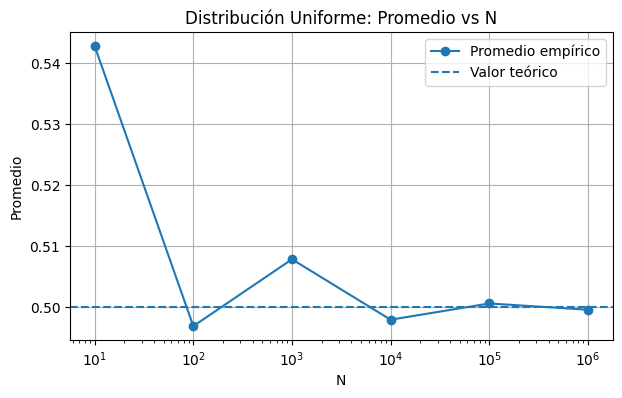

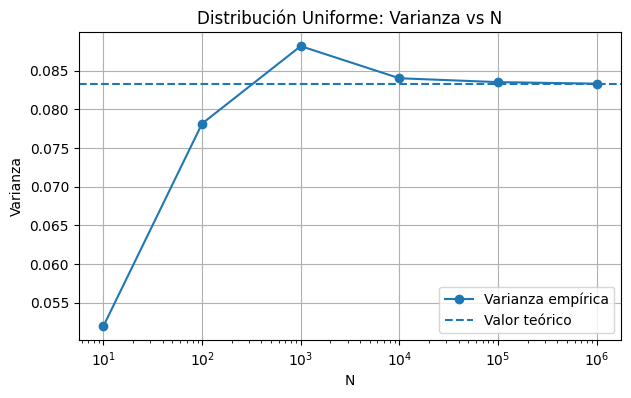

In [13]:
#Distribución Uniforme

media_uniforme = (a+b)/2
var_uniforme = (b-a)**2/12

estudiar_distribucion("Distribución Uniforme",lambda N: np.random.uniform(a,b,N),media_uniforme,var_uniforme)

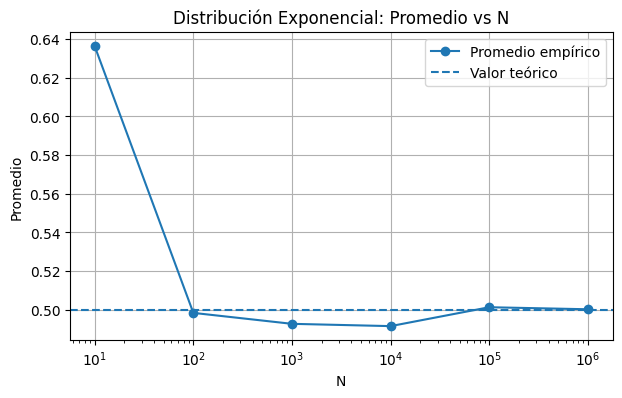

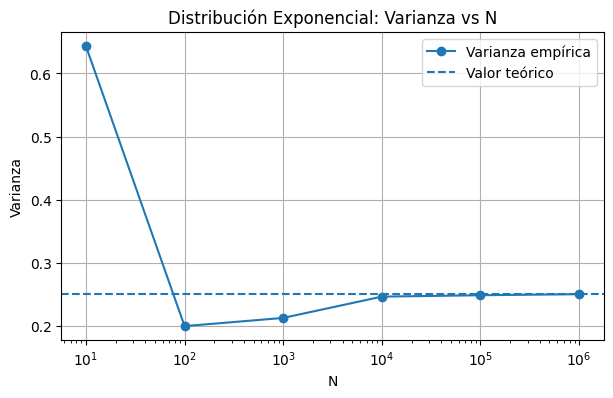

In [14]:
#Distribución Exponencial

media_exp = 1/lam
var_exp = 1/(lam**2)

estudiar_distribucion("Distribución Exponencial",lambda N: np.random.exponential(scale=1/lam,size=N),media_exp,var_exp)

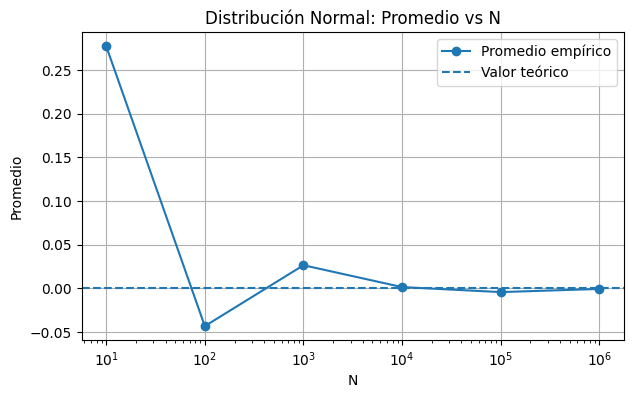

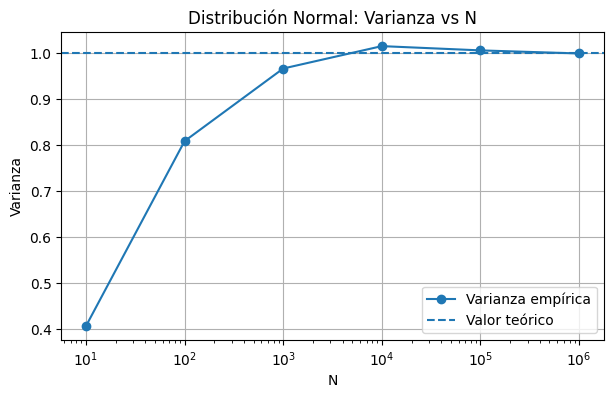

In [15]:
#Distribución Normal

media_normal = mu
var_normal = sigma**2

estudiar_distribucion("Distribución Normal",lambda N: np.random.normal(mu,sigma,N),media_normal,var_normal)

Los resultados cuantitativos confirman que conforme crece el número de observaciones (N), tanto la media como la varianza observadas se estabilizan en torno a los valores teóricos en las tres distribuciones evaluadas. Este fenómeno se alinea con la Ley Débil de los Grandes Números, un principio estadístico que anticipa la aproximación de los promedios muestrales al valor esperado ideal a medida que la muestra se expande.